<a href="https://colab.research.google.com/github/orcuncakaar/hantavirus-data-science-project/blob/main/Hantavirus_Data_Science_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import os

# İnceleyeceğimiz temel dosyalar
files_to_check = [
    "hantavirus_country_yearly.csv",
    "hantavirus_clinical.csv",
    "hantavirus_environmental.csv"
]

results = {}

for file in files_to_check:
    if os.path.exists(file):
        df = pd.read_csv(file)

        print(f"--- Veri Seti: {file} ---")
        print(f"Boyut (Satır, Sütun): {df.shape}")

        missing_values = df.isnull().sum()
        missing_values = missing_values[missing_values > 0]
        if not missing_values.empty:
            print("Eksik Değerler:")
            print(missing_values)
        else:
            print("Eksik Değer: Yok")

        print("\nSütun Tipleri ve Genel Bilgi:")
        df.info()
        print("\nİlk 3 Satır:")
        print(df.head(3))
        print("="*50 + "\n")
    else:
        print(f"Dosya bulunamadı: {file}")

--- Veri Seti: hantavirus_country_yearly.csv ---
Boyut (Satır, Sütun): (850, 14)
Eksik Değer: Yok

Sütun Tipleri ve Genel Bilgi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  850 non-null    int64  
 1   iso3                  850 non-null    object 
 2   country               850 non-null    object 
 3   who_region            850 non-null    object 
 4   latitude              850 non-null    float64
 5   longitude             850 non-null    float64
 6   syndrome              850 non-null    object 
 7   confirmed_cases       850 non-null    int64  
 8   deaths                850 non-null    int64  
 9   recovered             850 non-null    int64  
 10  case_fatality_rate    850 non-null    float64
 11  hospitalized          850 non-null    int64  
 12  icu_admissions        850 non-null    int64  
 

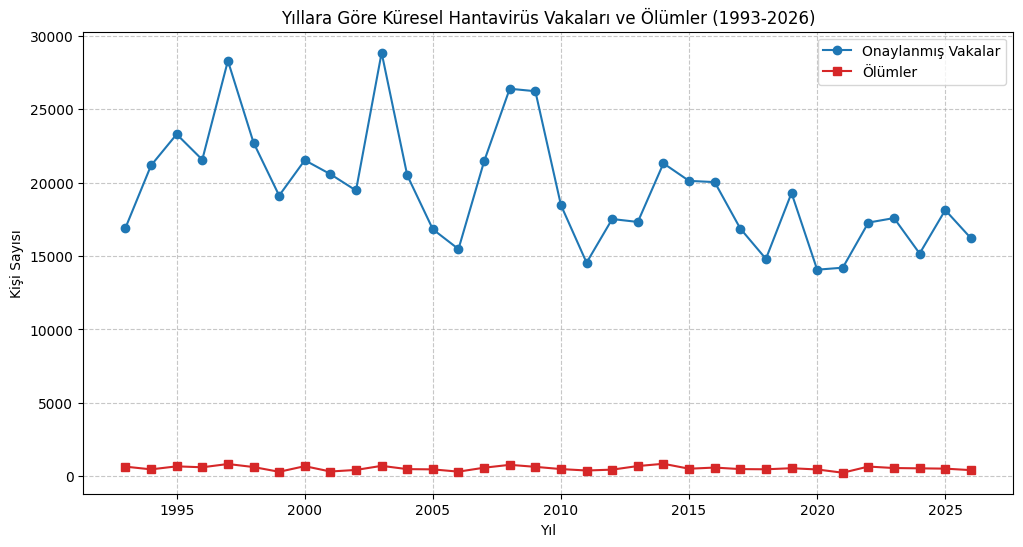

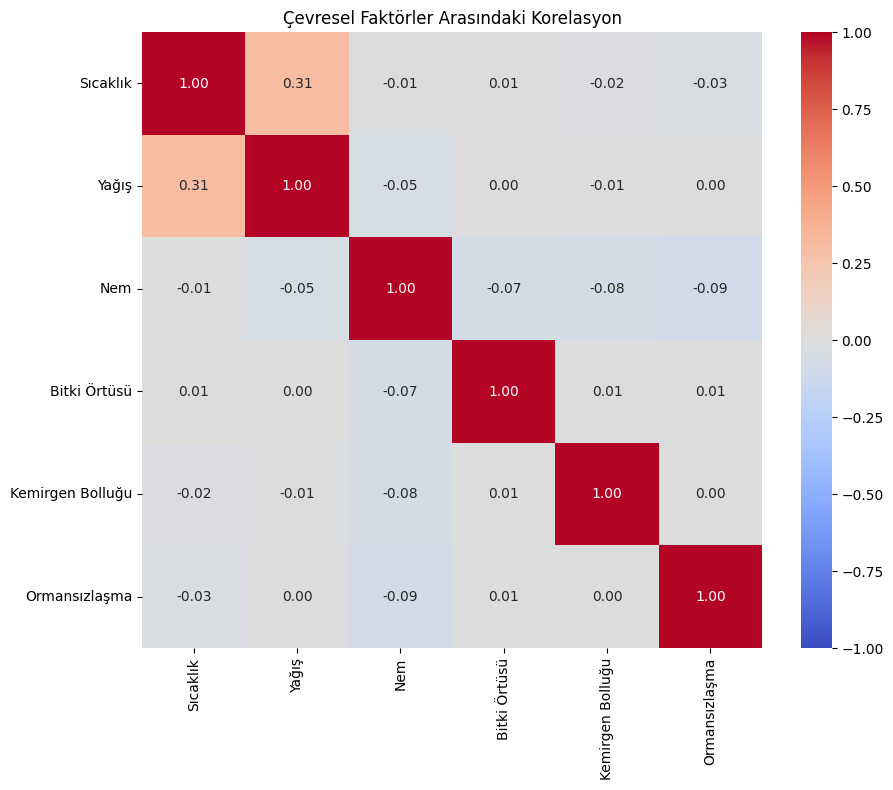

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

df_yearly = pd.read_csv('hantavirus_country_yearly.csv')
df_env = pd.read_csv('hantavirus_environmental.csv')

global_yearly = df_yearly.groupby('year')[['confirmed_cases', 'deaths']].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(global_yearly['year'], global_yearly['confirmed_cases'], marker='o', label='Onaylanmış Vakalar', color='#1f77b4')
plt.plot(global_yearly['year'], global_yearly['deaths'], marker='s', label='Ölümler', color='#d62728')
plt.title('Yıllara Göre Küresel Hantavirüs Vakaları ve Ölümler (1993-2026)')
plt.xlabel('Yıl')
plt.ylabel('Kişi Sayısı')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('kuresel_trend.png')

env_cols = ['mean_temperature_c', 'quarterly_rainfall_mm', 'relative_humidity_pct',
            'ndvi', 'rodent_abundance_index', 'deforestation_rate_pct']
corr_matrix = df_env[env_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1,
            xticklabels=['Sıcaklık', 'Yağış', 'Nem', 'Bitki Örtüsü', 'Kemirgen Bolluğu', 'Ormansızlaşma'],
            yticklabels=['Sıcaklık', 'Yağış', 'Nem', 'Bitki Örtüsü', 'Kemirgen Bolluğu', 'Ormansızlaşma'])
plt.title('Çevresel Faktörler Arasındaki Korelasyon')
plt.savefig('cevresel_korelasyon.png')

/tmp/ipykernel_5750/1745014063.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x='confirmed_cases', y='country', palette='viridis')


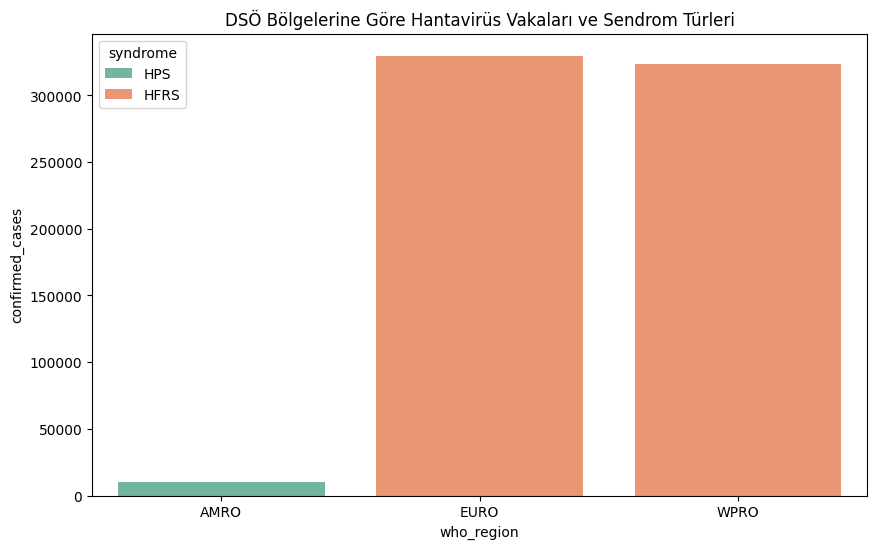

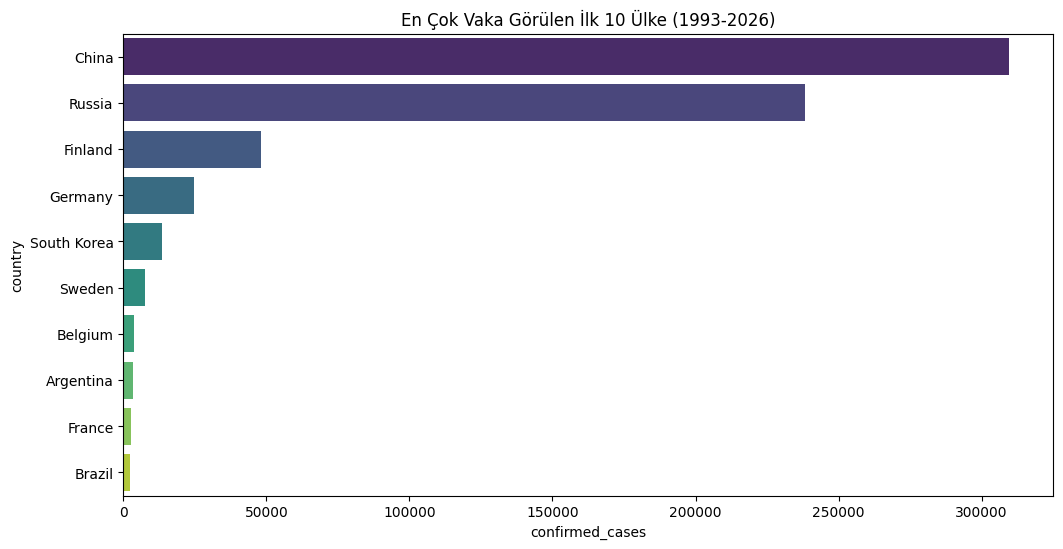

In [22]:
df_yearly = pd.read_csv('hantavirus_country_yearly.csv')

# 1. Bölge ve Sendroma Göre Analiz
region_syndrome = df_yearly.groupby(['who_region', 'syndrome'])['confirmed_cases'].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=region_syndrome, x='who_region', y='confirmed_cases', hue='syndrome', palette='Set2')
plt.title('DSÖ Bölgelerine Göre Hantavirüs Vakaları ve Sendrom Türleri')
plt.savefig('bolgesel_sendrom_dagilimi.png')

# 2. En Çok Vaka Görülen 10 Ülke
top_countries = df_yearly.groupby('country')['confirmed_cases'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries, x='confirmed_cases', y='country', palette='viridis')
plt.title('En Çok Vaka Görülen İlk 10 Ülke (1993-2026)')
plt.savefig('top_10_ulke.png')

/tmp/ipykernel_5750/584715628.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=syndrome_stats, x='syndrome', y='cfr_percent', palette=['#ff9999', '#66b3ff'])


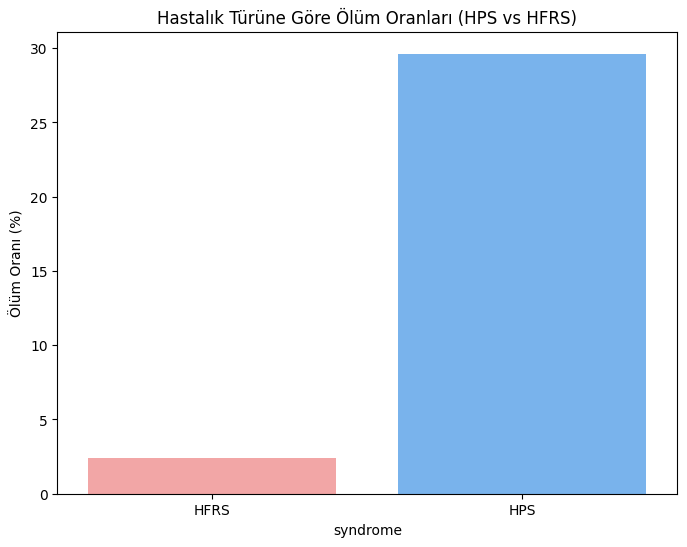

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_yearly = pd.read_csv('hantavirus_country_yearly.csv')

# Sendromlara göre toplam vaka ve ölümleri toplayıp oranı hesaplıyoruz
syndrome_stats = df_yearly.groupby('syndrome')[['confirmed_cases', 'deaths']].sum().reset_index()
syndrome_stats['cfr_percent'] = (syndrome_stats['deaths'] / syndrome_stats['confirmed_cases']) * 100

plt.figure(figsize=(8, 6))
sns.barplot(data=syndrome_stats, x='syndrome', y='cfr_percent', palette=['#ff9999', '#66b3ff'])
plt.title('Hastalık Türüne Göre Ölüm Oranları (HPS vs HFRS)')
plt.ylabel('Ölüm Oranı (%)')
plt.savefig('olum_oranlari_karsilastirmasi.png')

/tmp/ipykernel_5750/2009656129.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sex_mortality = df_clinical.groupby(['age_group', 'sex'])['is_deceased'].mean().reset_index()


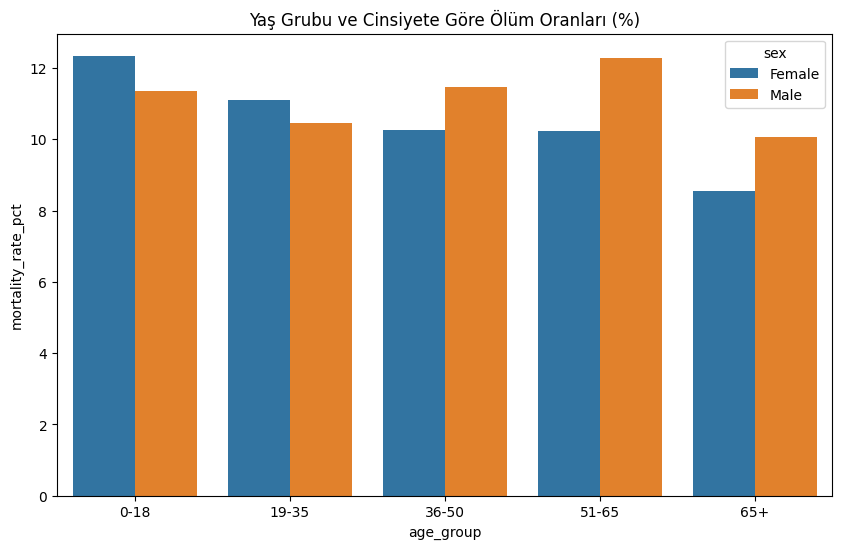

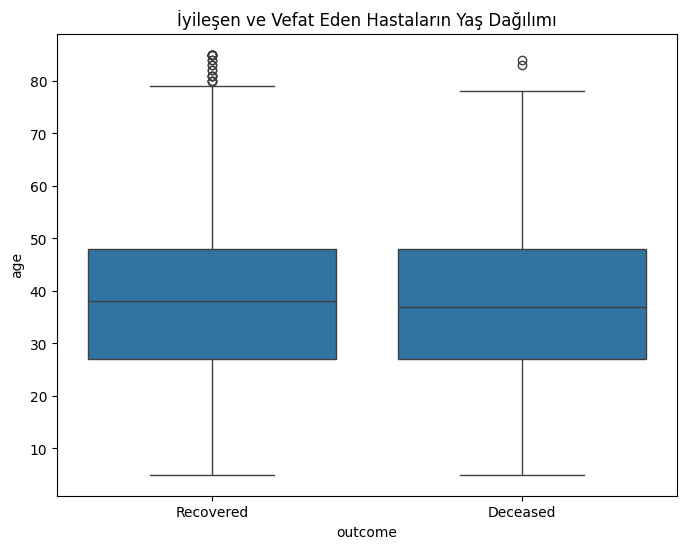

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi yükleme ve Vefat durumunu (Deceased) yüzdeye çevirmek için sayısal formata getirme
df_clinical = pd.read_csv('hantavirus_clinical.csv')
df_clinical['is_deceased'] = (df_clinical['outcome'] == 'Deceased').astype(int)

# Hastaları Yaş Gruplarına Ayırma
bins = [0, 18, 35, 50, 65, 120]
labels = ['0-18', '19-35', '36-50', '51-65', '65+']
df_clinical['age_group'] = pd.cut(df_clinical['age'], bins=bins, labels=labels)

# Yaş grubu ve cinsiyete göre ölüm oranlarını hesaplama
age_sex_mortality = df_clinical.groupby(['age_group', 'sex'])['is_deceased'].mean().reset_index()
age_sex_mortality['mortality_rate_pct'] = age_sex_mortality['is_deceased'] * 100

# Grafik 1 (Bar Chart): Yaş ve Cinsiyete Göre Ölüm Oranları
plt.figure(figsize=(10, 6))
sns.barplot(data=age_sex_mortality, x='age_group', y='mortality_rate_pct', hue='sex')
plt.title('Yaş Grubu ve Cinsiyete Göre Ölüm Oranları (%)')
plt.savefig('yas_cinsiyet_olum_orani.png')

# Grafik 2 (Kutu Grafiği): İyileşen ve Vefat Edenlerin Yaş Dağılımı
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clinical, x='outcome', y='age')
plt.title('İyileşen ve Vefat Eden Hastaların Yaş Dağılımı')
plt.savefig('yas_dagilimi_sonuc.png')

In [26]:
import pandas as pd

# 1. Virüs Suşları (Strains) ve İnsandan İnsana Bulaşma Durumu
try:
    df_strains = pd.read_csv('hantavirus_virus_strains.csv')
    h2h_strains = df_strains[df_strains['h2h_transmission'] == 'Yes']
    print("--- İnsandan İnsana Bulaşabilen Virüs Suşları ---")
    if not h2h_strains.empty:
        print(h2h_strains[['strain_name', 'region', 'reservoir_host', 'h2h_transmission']])
    else:
        print("Kayıtlarda insandan insana bulaşan suş bulunamadı.")
except FileNotFoundError:
    print("hantavirus_virus_strains.csv bulunamadı.")

print("\n")

# 2. Yıllara Göre İnsandan İnsana Bulaşma Vakalarının Trendi
try:
    df_yearly = pd.read_csv('hantavirus_country_yearly.csv')
    h2h_yearly = df_yearly.groupby('year')['human_to_human_cases'].sum().reset_index()
    total_h2h = h2h_yearly['human_to_human_cases'].sum()

    print(f"--- Yıllara Göre Toplam İnsandan İnsana Bulaşma Vaka Sayısı: {total_h2h} ---")
    # Sadece H2H vakası olan yılları gösterelim
    h2h_active_years = h2h_yearly[h2h_yearly['human_to_human_cases'] > 0]
    print(h2h_active_years.tail(10)) # Son 10 yılı göster
except FileNotFoundError:
    print("hantavirus_country_yearly.csv bulunamadı.")

--- İnsandan İnsana Bulaşabilen Virüs Suşları ---
Kayıtlarda insandan insana bulaşan suş bulunamadı.


--- Yıllara Göre Toplam İnsandan İnsana Bulaşma Vaka Sayısı: 103 ---
    year  human_to_human_cases
24  2017                     2
25  2018                     2
26  2019                     8
27  2020                     7
28  2021                     5
29  2022                     4
30  2023                     4
31  2024                     5
32  2025                     8
33  2026                     4


--- MODEL DEĞERLENDİRME SONUÇLARI ---
R-Kare (R2) Skoru: -0.0357
Hata Kareler Ortalaması (MSE): 0.0706
----------------------------------------

Modelin Karar Mekanizması (Hangi Gecikmeli Faktör Ne Kadar Etkili?):


,Ekolojik Faktör,Etki Ağırlığı (%)
1,rainfall_lag1,19.707812
4,ndvi_lag2,17.945549
5,deforestation_rate_pct,16.365449
3,ndvi_lag1,16.248280
2,rainfall_lag2,14.950745
0,mean_temperature_c,14.782166


/tmp/ipykernel_5750/2802779883.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='Etki Ağırlığı (%)', y='Ekolojik Faktör', palette='viridis')


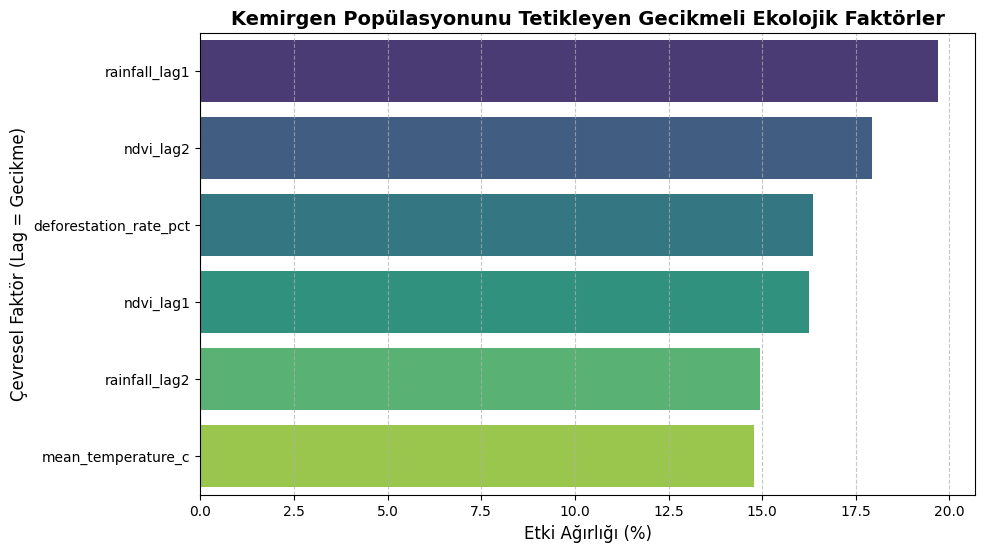

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import display

# 1. Veriyi Yükleme
# Not: 'hantavirus_environmental.csv' dosyasının Colab'e yüklendiğinden emin ol.
df_env = pd.read_csv('hantavirus_environmental.csv')

# 2. Gecikmeli (Lagged) Özelliklerin Oluşturulması
# Doğadaki zincirleme reaksiyonları (ör. 6 ay önceki yağışın bugünkü fareye etkisi) modelliyoruz
df_env = df_env.sort_values(by=['region', 'year', 'quarter'])

df_env['rainfall_lag1'] = df_env.groupby('region')['quarterly_rainfall_mm'].shift(1)  # 3 ay önceki yağış
df_env['rainfall_lag2'] = df_env.groupby('region')['quarterly_rainfall_mm'].shift(2)  # 6 ay önceki yağış
df_env['ndvi_lag1'] = df_env.groupby('region')['ndvi'].shift(1)                       # 3 ay önceki bitki örtüsü
df_env['ndvi_lag2'] = df_env.groupby('region')['ndvi'].shift(2)                       # 6 ay önceki bitki örtüsü

# Kaydırma (shift) işlemi sonrası oluşan eksik verileri (NaN) temizleme
df_lagged = df_env.dropna().copy()

# 3. Model Kurulumu
features_lagged = [
    'mean_temperature_c', 'rainfall_lag1', 'rainfall_lag2',
    'ndvi_lag1', 'ndvi_lag2', 'deforestation_rate_pct'
]

X = df_lagged[features_lagged]
y = df_lagged['rodent_abundance_index']

# Veriyi %80 Eğitim, %20 Test olarak ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Regresyon Modeli
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Tahmin ve Başarı Metrikleri
y_pred = model.predict(X_test)

print("--- MODEL DEĞERLENDİRME SONUÇLARI ---")
print(f"R-Kare (R2) Skoru: {r2_score(y_test, y_pred):.4f}")
print(f"Hata Kareler Ortalaması (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print("-" * 40)

# 5. Özellik Önemi (Feature Importance) Tablosu
importances = model.feature_importances_
fi_df = pd.DataFrame({
    'Ekolojik Faktör': features_lagged,
    'Etki Ağırlığı (%)': importances * 100
}).sort_values(by='Etki Ağırlığı (%)', ascending=False)

print("\nModelin Karar Mekanizması (Hangi Gecikmeli Faktör Ne Kadar Etkili?):")
# display() fonksiyonu Colab'de tabloyu interaktif ve şık bir Pandas formatında gösterir
display(fi_df)

# 6. Özellik Önemi Görselleştirme
plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df, x='Etki Ağırlığı (%)', y='Ekolojik Faktör', palette='viridis')

plt.title('Kemirgen Popülasyonunu Tetikleyen Gecikmeli Ekolojik Faktörler', fontsize=14, fontweight='bold')
plt.xlabel('Etki Ağırlığı (%)', fontsize=12)
plt.ylabel('Çevresel Faktör (Lag = Gecikme)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Colab ortamında grafiği hücrenin hemen altında göstermek için:
plt.show()

📌 Yıllık Ortalama Sıcaklık ile Toplam Vaka Arasındaki Korelasyon: -0.2576



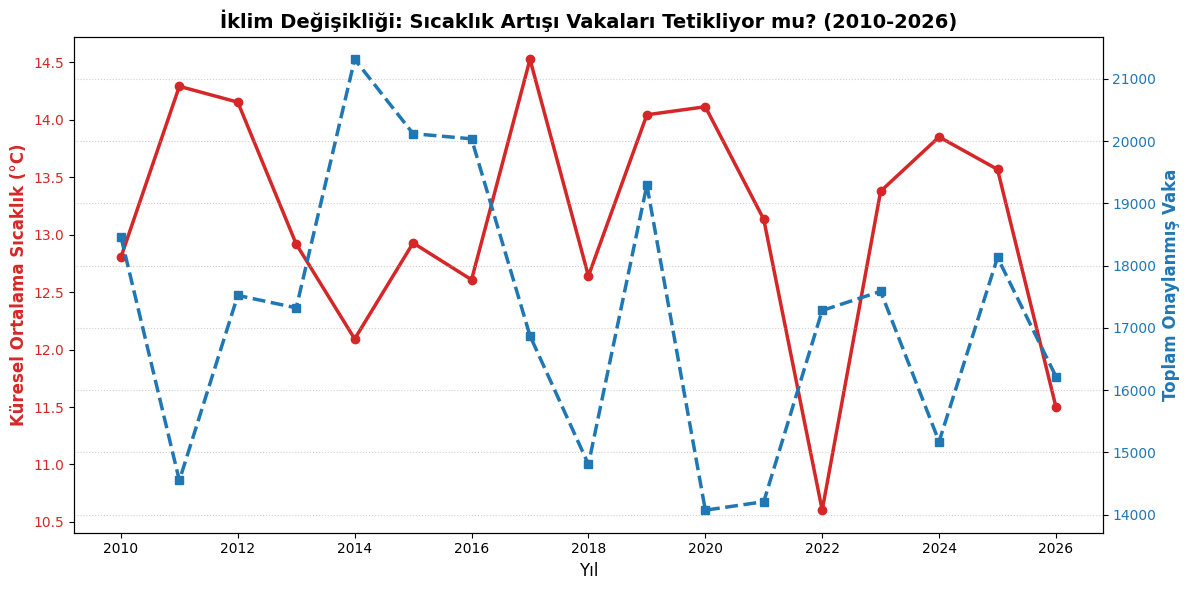

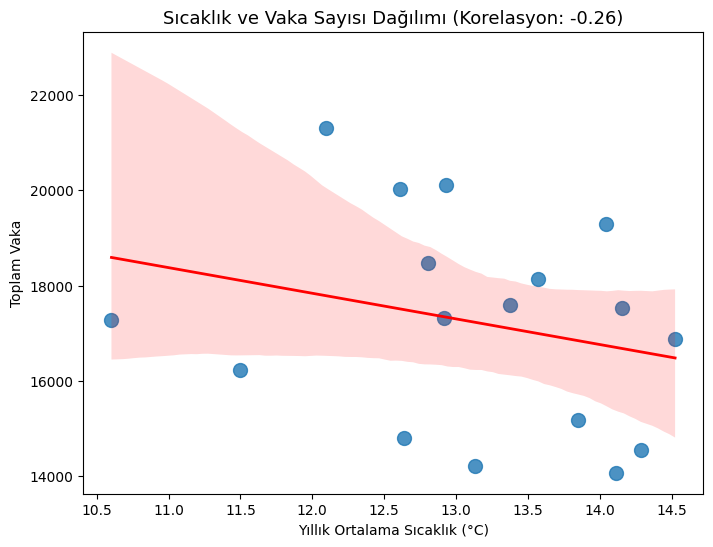

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 1. Verileri Yükleme ve Yıla Göre Gruplama
df_yearly = pd.read_csv('hantavirus_country_yearly.csv')
df_env = pd.read_csv('hantavirus_environmental.csv')

# Yıllık toplam vaka ve yıllık ortalama sıcaklığı hesaplıyoruz
yearly_cases = df_yearly.groupby('year')['confirmed_cases'].sum().reset_index()
yearly_temp = df_env.groupby('year')['mean_temperature_c'].mean().reset_index()

# 2. Veri Setlerini Birleştirme (Sadece kesişen 2010-2026 yılları)
df_climate = pd.merge(yearly_cases, yearly_temp, on='year', how='inner')

# 3. Korelasyon Hesaplama
corr = df_climate['confirmed_cases'].corr(df_climate['mean_temperature_c'])
print(f"📌 Yıllık Ortalama Sıcaklık ile Toplam Vaka Arasındaki Korelasyon: {corr:.4f}\n")

# 4. Çift Eksenli (Dual-Axis) Trend Grafiği Çizimi
fig, ax1 = plt.subplots(figsize=(12, 6))

# Sol Eksen: Sıcaklık (Kırmızı)
color1 = '#d62728'
ax1.set_xlabel('Yıl', fontsize=12)
ax1.set_ylabel('Küresel Ortalama Sıcaklık (°C)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(df_climate['year'], df_climate['mean_temperature_c'], color=color1, marker='o', linewidth=2.5, label='Sıcaklık Trendi')
ax1.tick_params(axis='y', labelcolor=color1)

# Sağ Eksen: Vaka Sayısı (Mavi)
ax2 = ax1.twinx()
color2 = '#1f77b4'
ax2.set_ylabel('Toplam Onaylanmış Vaka', color=color2, fontsize=12, fontweight='bold')
ax2.plot(df_climate['year'], df_climate['confirmed_cases'], color=color2, marker='s', linestyle='--', linewidth=2.5, label='Vaka Trendi')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('İklim Değişikliği: Sıcaklık Artışı Vakaları Tetikliyor mu? (2010-2026)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 5. Dağılım ve Regresyon Grafiği (Scatter Plot)
plt.figure(figsize=(8, 6))
sns.regplot(data=df_climate, x='mean_temperature_c', y='confirmed_cases',
            scatter_kws={'alpha':0.8, 's':100}, line_kws={'color':'red', 'linewidth':2})
plt.title(f'Sıcaklık ve Vaka Sayısı Dağılımı (Korelasyon: {corr:.2f})', fontsize=13)
plt.xlabel('Yıllık Ortalama Sıcaklık (°C)')
plt.ylabel('Toplam Vaka')
plt.show()

In [36]:
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display

# 1. Çevresel Veriyi Yükle
df_env = pd.read_csv('hantavirus_environmental.csv')

# 2. Risk Skoru İçin Kullanılacak Sütunlar
cols_for_risk = ['relative_humidity_pct', 'mean_temperature_c', 'rodent_abundance_index', 'deforestation_rate_pct']

# Verileri 0-1 aralığına standardize et
scaler = MinMaxScaler()
df_scaled = df_env.copy()
df_scaled[cols_for_risk] = scaler.fit_transform(df_env[cols_for_risk])

# 3. Ağırlıklı Risk Skorunu Hesapla (0-100 Arası)
weights = {
    'relative_humidity_pct': 0.25,
    'mean_temperature_c': 0.25,
    'rodent_abundance_index': 0.30,
    'deforestation_rate_pct': 0.20
}

df_env['risk_score'] = (
    df_scaled['relative_humidity_pct'] * weights['relative_humidity_pct'] +
    df_scaled['mean_temperature_c'] * weights['mean_temperature_c'] +
    df_scaled['rodent_abundance_index'] * weights['rodent_abundance_index'] +
    df_scaled['deforestation_rate_pct'] * weights['deforestation_rate_pct']
) * 100

# 4. Bölge Bazında Ortalama Riski Hesapla (Tüm Dünya)
region_risk = df_env.groupby(['region', 'latitude', 'longitude'])['risk_score'].mean().reset_index()
region_risk = region_risk.sort_values(by='risk_score', ascending=False)

# 5. DETAYLI DÜNYA HARİTASI (Plotly Mapbox)
fig = px.scatter_mapbox(
    region_risk,
    lat="latitude",
    lon="longitude",
    color="risk_score",
    size="risk_score",
    hover_name="region",
    hover_data={"latitude": False, "longitude": False, "risk_score": ":.1f"},
    color_continuous_scale=px.colors.sequential.YlOrRd,
    size_max=25,          # Baloncukların maksimum büyüklüğü
    zoom=1.2,             # Başlangıç yakınlaştırma seviyesi (Tüm dünyayı gösterecek şekilde)
    mapbox_style="carto-positron",  # Çok temiz, anlaşılır ve detaylı harita stili
    title="🌍 Detaylı Küresel Hantavirüs Çevresel Risk Haritası"
)

# Haritanın kenar boşluklarını sıfırlayıp tam ekran görünümünü iyileştirme
fig.update_layout(
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    title_x=0.5,
    title_font_size=18,
    title_font_family="Arial",
)

# Haritayı Colab'de göster
fig.show()